In [21]:
import pandas as pd
import numpy as np
import sqlalchemy
import seaborn as sns
import requests
import matplotlib.pyplot as plt 
from statsmodels.tsa.seasonal import STL

In [22]:
residuals = pd.read_csv('residual_analysis_results.csv')
trend = pd.read_csv('trend_analysis_results.csv')
seasonality_daily = pd.read_csv('seasonality_results_daily.csv')
seasonality_weekly = pd.read_csv('seasonality_results_weekly.csv')


### Trend

In [23]:
# Calculate the percentage of each trend category
trend_counts = trend['trend_category'].value_counts(normalize=True) * 100

print("Directional Composition of the Population:")
print(f"% Increasing: {trend_counts.get('Increasing', 0):.2f}%")
print(f"% Decreasing: {trend_counts.get('Decreasing', 0):.2f}%")
print(f"% Stable: {trend_counts.get('Stable', 0):.2f}%")

Directional Composition of the Population:
% Increasing: 34.19%
% Decreasing: 29.27%
% Stable: 36.55%


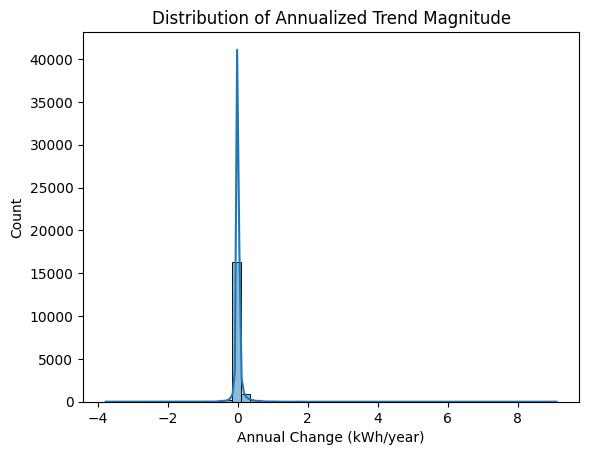

Mean annual structural drift: 0.0104 kWh per year
Median annual structural drift: 0.0007 kWh per year


In [24]:

trend['annual_change'] = trend['trend_slope'] * 24 * 365

# Distribution plot
sns.histplot(trend['annual_change'], bins=50, kde=True)
plt.xlabel('Annual Change (kWh/year)')
plt.title('Distribution of Annualized Trend Magnitude')
plt.show()

# Mean and median annual change
mean_annual_change = trend['annual_change'].mean()
median_annual_change = trend['annual_change'].median()

print(f"Mean annual structural drift: {mean_annual_change:.4f} kWh per year")
print(f"Median annual structural drift: {median_annual_change:.4f} kWh per year")

Correlation between annual trend change and weekly seasonality strength: 0.021
Correlation between trend volatility and weekly seasonality strength: -0.208


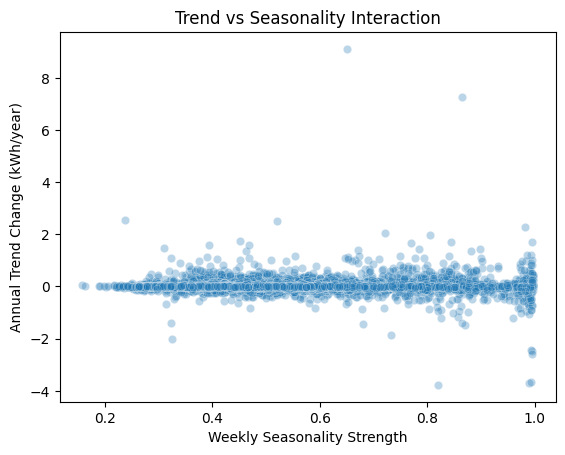

In [25]:
# Merge trend and seasonality_weekly dataframes on 'user'
trend_seasonality = pd.merge(trend, seasonality_weekly[['user', 'seasonal_strength_weekly']], on='user')

# Correlation between annual trend change and weekly seasonality strength
corr_trend_seasonality = trend_seasonality['annual_change'].corr(trend_seasonality['seasonal_strength_weekly'])
print(f"Correlation between annual trend change and weekly seasonality strength: {corr_trend_seasonality:.3f}")

# Are highly seasonal users more stable? (correlate seasonality with trend_volatility)
corr_volatility_seasonality = trend_seasonality['trend_volatility'].corr(trend_seasonality['seasonal_strength_weekly'])
print(f"Correlation between trend volatility and weekly seasonality strength: {corr_volatility_seasonality:.3f}")

# Optional: visualize
sns.scatterplot(
    x='seasonal_strength_weekly',
    y='annual_change',
    data=trend_seasonality,
    alpha=0.3
)
plt.xlabel('Weekly Seasonality Strength')
plt.ylabel('Annual Trend Change (kWh/year)')
plt.title('Trend vs Seasonality Interaction')
plt.show()

In [26]:
# Define thresholds for stability and trend magnitude
volatility_threshold = trend['trend_volatility'].median()
annual_change_threshold = trend['annual_change'].abs().median()

def classify_user(row):
    stable = row['trend_volatility'] <= volatility_threshold
    increasing = abs(row['annual_change']) > annual_change_threshold
    if stable and not increasing:
        return 'Stable & Flat'
    elif stable and increasing:
        return 'Stable & Increasing'
    elif not stable and not increasing:
        return 'Volatile & Flat'
    else:
        return 'Volatile & Increasing'

trend['user_typology'] = trend.apply(classify_user, axis=1)

# Show counts for each typology
print(trend['user_typology'].value_counts())

user_typology
Volatile & Increasing    5505
Stable & Flat            5487
Volatile & Flat          3448
Stable & Increasing      3430
Name: count, dtype: int64


### Residual

In [27]:
# Drop NaNs to avoid issues with quantile calculation
residual_cv_nonan = residuals['residual_cv'].dropna()

# Compute quartile thresholds
low_threshold = residual_cv_nonan.quantile(0.25)
high_threshold = residual_cv_nonan.quantile(0.75)

def classify_noise(cv):
    if pd.isna(cv):
        return 'Unknown'
    elif cv <= low_threshold:
        return 'Low noise'
    elif cv <= high_threshold:
        return 'Medium noise'
    else:
        return 'High noise'

residuals['noise_regime'] = residuals['residual_cv'].apply(classify_noise)

# Show counts for each regime
print(residuals['noise_regime'].value_counts())

noise_regime
Medium noise    8916
Low noise       4459
High noise      4458
Unknown           37
Name: count, dtype: int64


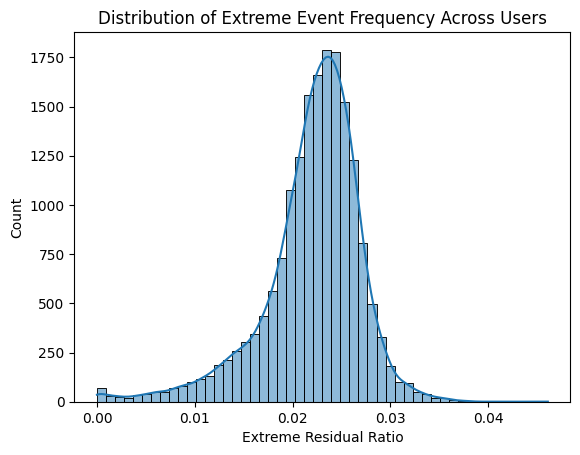

In [28]:
# Plot the distribution of extreme_residual_ratio across the population
sns.histplot(residuals['extreme_residual_ratio'], bins=50, kde=True)
plt.xlabel('Extreme Residual Ratio')
plt.title('Distribution of Extreme Event Frequency Across Users')
plt.show()

In [29]:
# Calculate percentage of users with high residual kurtosis
total_users = residuals['residual_kurtosis'].notna().sum()
pct_kurtosis_gt_5 = (residuals['residual_kurtosis'] > 5).sum() / total_users * 100
pct_kurtosis_gt_10 = (residuals['residual_kurtosis'] > 10).sum() / total_users * 100

print(f"% users with residual kurtosis > 5: {pct_kurtosis_gt_5:.2f}%")
print(f"% users with residual kurtosis > 10: {pct_kurtosis_gt_10:.2f}%")

% users with residual kurtosis > 5: 99.42%
% users with residual kurtosis > 10: 83.27%


In [30]:
# Residual vs Seasonality (Very Powerful)

# Merge residuals and seasonality_weekly on 'user'
residual_seasonality = pd.merge(
    residuals[['user', 'residual_cv']],
    seasonality_weekly[['user', 'seasonal_strength_weekly']],
    on='user'
)

# Test: Do highly seasonal users have lower noise?
corr_seasonality_noise = residual_seasonality['seasonal_strength_weekly'].corr(residual_seasonality['residual_cv'])
print(f"Correlation between weekly seasonality strength and residual noise (CV): {corr_seasonality_noise:.3f}")

if corr_seasonality_noise < 0:
    print("Stronger structure → lower unpredictability")
    print("That’s a beautiful structural insight.")

Correlation between weekly seasonality strength and residual noise (CV): -0.181
Stronger structure → lower unpredictability
That’s a beautiful structural insight.


### Merge residual and trend 

Correlation Matrix:
                          annual_change  trend_volatility  \
annual_change                  1.000000          0.022691   
trend_volatility               0.022691          1.000000   
seasonal_strength_daily        0.013832         -0.130905   
seasonal_strength_weekly       0.020682         -0.207716   
residual_cv                   -0.003581          0.698443   
residual_kurtosis             -0.008548          0.423542   

                          seasonal_strength_daily  seasonal_strength_weekly  \
annual_change                            0.013832                  0.020682   
trend_volatility                        -0.130905                 -0.207716   
seasonal_strength_daily                  1.000000                  0.912559   
seasonal_strength_weekly                 0.912559                  1.000000   
residual_cv                             -0.173779                 -0.180963   
residual_kurtosis                       -0.114538                 -0.119891   

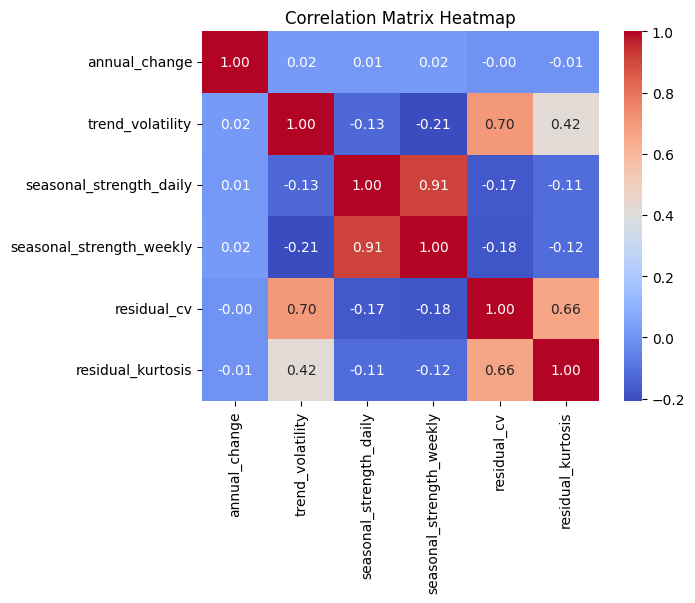

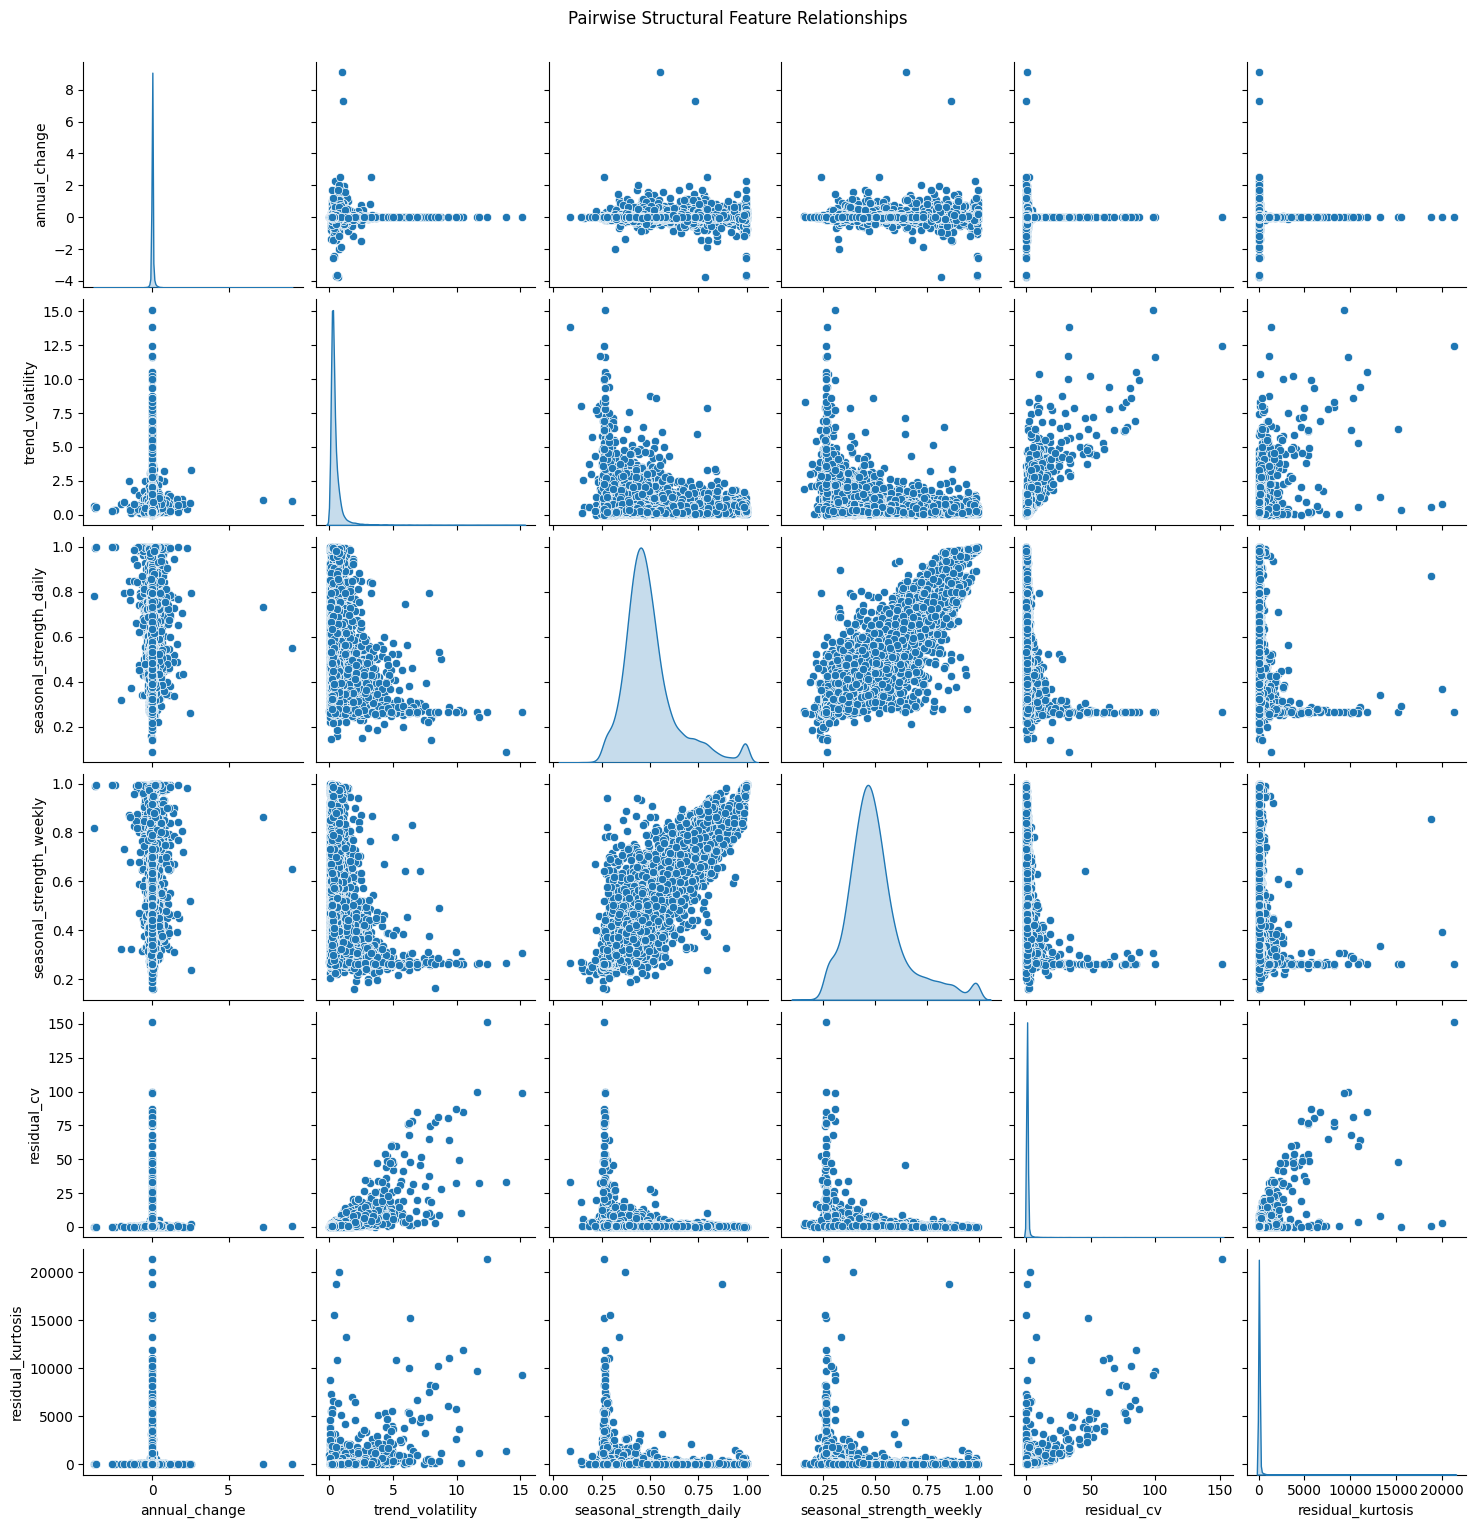

Archetype counts:
archetype
0.0    14499
3.0     2760
2.0      530
1.0       44
Name: count, dtype: int64


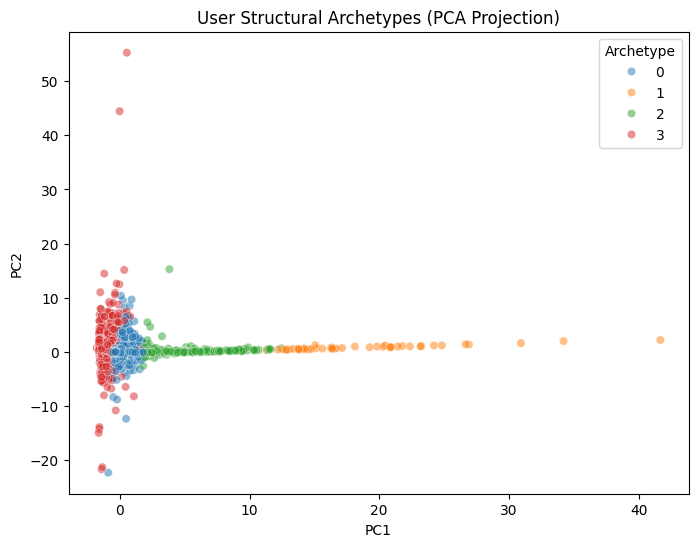

In [36]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 4.X Structural Interaction Between Components

# Merge all relevant features into a unified structural dataframe
structural_df = trend[['user', 'annual_change', 'trend_volatility']].merge(
    seasonality_daily[['user', 'seasonal_strength_daily']], on='user'
).merge(
    seasonality_weekly[['user', 'seasonal_strength_weekly']], on='user'
).merge(
    residuals[['user', 'residual_cv', 'residual_kurtosis']], on='user'
)

# Compute correlation matrix for structural features
corr_matrix = structural_df.drop('user', axis=1).corr()
print("Correlation Matrix:")
print(corr_matrix)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()
# Visualize pairwise relationships
sns.pairplot(structural_df.drop('user', axis=1), diag_kind='kde')
plt.suptitle('Pairwise Structural Feature Relationships', y=1.02)
plt.show()

# Example: Cluster users into archetypes using KMeans

features = ['annual_change', 'trend_volatility', 'seasonal_strength_weekly', 'residual_cv']
X = structural_df[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
archetype_labels = kmeans.fit_predict(X_scaled)

# Assign archetype labels to the dataframe
structural_df.loc[X.index, 'archetype'] = archetype_labels

# Show archetype counts
print("Archetype counts:")
print(structural_df['archetype'].value_counts())

# Optional: Visualize archetypes in 2D (e.g., using first two principal components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=archetype_labels, palette='tab10', alpha=0.5)
plt.title('User Structural Archetypes (PCA Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Archetype')
plt.show()

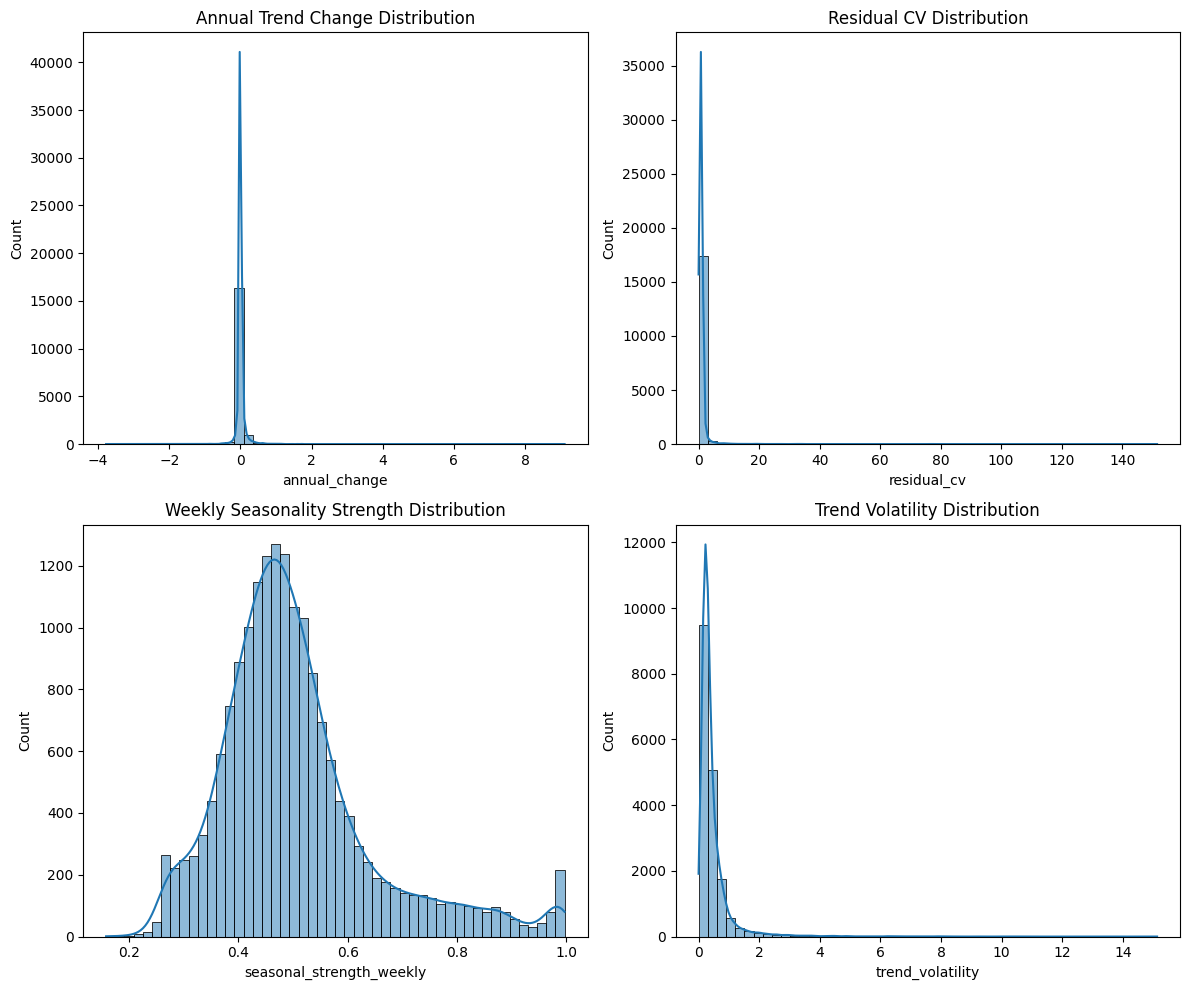

Correlation Matrix:
                          annual_change  trend_volatility  \
annual_change                  1.000000          0.022691   
trend_volatility               0.022691          1.000000   
seasonal_strength_daily        0.013832         -0.130905   
seasonal_strength_weekly       0.020682         -0.207716   
residual_cv                   -0.003581          0.698443   
residual_kurtosis             -0.008548          0.423542   

                          seasonal_strength_daily  seasonal_strength_weekly  \
annual_change                            0.013832                  0.020682   
trend_volatility                        -0.130905                 -0.207716   
seasonal_strength_daily                  1.000000                  0.912559   
seasonal_strength_weekly                 0.912559                  1.000000   
residual_cv                             -0.173779                 -0.180963   
residual_kurtosis                       -0.114538                 -0.119891   

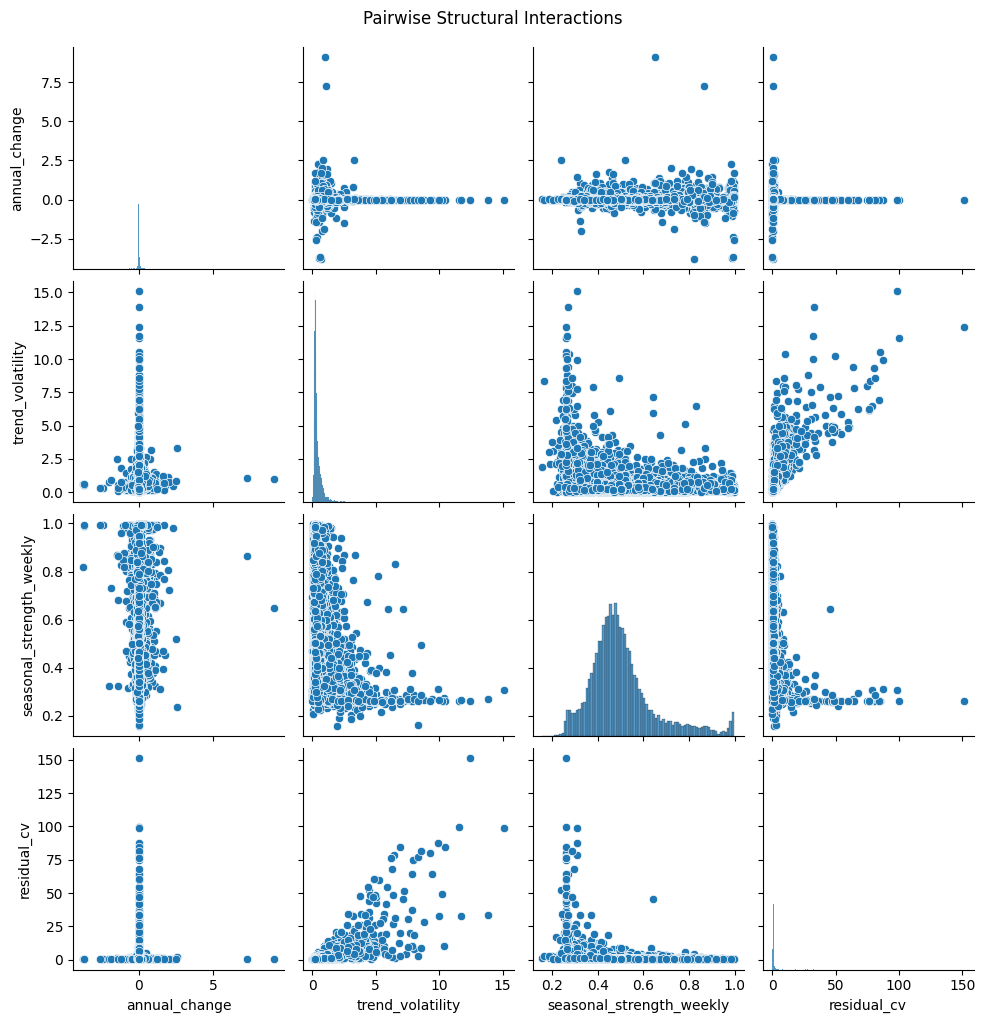

Structural Archetype Counts:
archetype
0.0    14499
3.0     2760
2.0      530
1.0       44
Name: count, dtype: int64


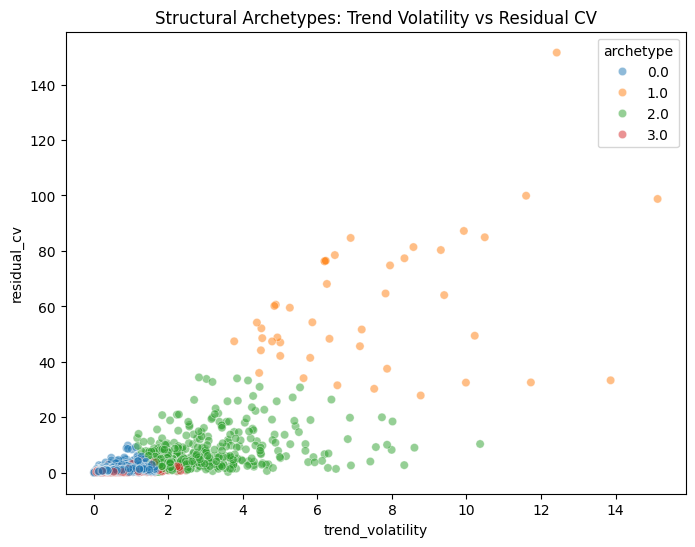

In [ ]:
# Plot a heatmap of the correlation matrix for the structural features


In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
OUTPUT_DIR
def analyze_results(suffix):
    # Read the CSV files
    daily_df   = pd.read_csv(OUTPUT_DIR / f"seasonality_results_daily_{suffix}.csv")
    weekly_df  = pd.read_csv(OUTPUT_DIR / f"seasonality_results_weekly_{suffix}.csv")
    trend_df   = pd.read_csv(OUTPUT_DIR / f"trend_analysis_results_{suffix}.csv")
    resid_df   = pd.read_csv(OUTPUT_DIR / f"residual_analysis_results_{suffix}.csv")

    # Seasonality analysis
    print(f"Daily seasonality: mean={daily_df['seasonal_strength_daily'].mean():.3f}, std={daily_df['seasonal_strength_daily'].std():.3f}")
    print(f"Weekly seasonality: mean={weekly_df['seasonal_strength_weekly'].mean():.3f}, std={weekly_df['seasonal_strength_weekly'].std():.3f}")

    # Trend analysis
    print(trend_df['trend_category'].value_counts())
    print(f"Trend slope: mean={trend_df['trend_slope'].mean():.4f}, std={trend_df['trend_slope'].std():.4f}")

    # Residuals analysis
    print(f"Residual std: mean={resid_df['residual_std'].mean():.3f}, std={resid_df['residual_std'].std():.3f}")
    print(f"Extreme residual ratio: mean={resid_df['extreme_residual_ratio'].mean():.3f}")

    # Example: plot histograms
    plt.figure(figsize=(12, 8))
    plt.subplot(2,2,1)
    plt.hist(daily_df['seasonal_strength_daily'].dropna(), bins=30)
    plt.title('Daily Seasonality Strength')
    plt.subplot(2,2,2)
    plt.hist(weekly_df['seasonal_strength_weekly'].dropna(), bins=30)
    plt.title('Weekly Seasonality Strength')
    plt.subplot(2,2,3)
    plt.hist(trend_df['trend_slope'].dropna(), bins=30)
    plt.title('Trend Slope')
    plt.subplot(2,2,4)
    plt.hist(resid_df['residual_std'].dropna(), bins=30)
    plt.title('Residual Std')
    plt.tight_layout()
    plt.show()
